# DermaXplain - HAM10000 preprocessing and inventory notebook

This notebook consolidates dataset preprocessing and sanity checks for the DermaXplain practicum.

## Objectives

- validate local dataset structure
- clean non-image files from image/mask folders
- standardise mask naming conventions
- build dataset inventory tables
- verify image/mask matching for ISIC 2018 and HAM10000
- inspect image resolution and aspect-ratio distributions
- inspect lesion mask coverage distributions
- inspect HAM10000 class distribution
- visualise representative image/mask/overlay examples
- save clean inventory manifests for later notebooks

## Naming convention

Masks have been renamed to match image stems directly:

- image: `ISIC_xxxxxxx.jpg`
- mask: `ISIC_xxxxxxx.png`

In [1]:
from pathlib import Path
from collections import Counter
import shutil
import random

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 30)

In [2]:
ROOT = Path("..")

ISIC_DIR = ROOT / "data" / "isic2018"
ISIC_IMG_DIR = ISIC_DIR / "images"
ISIC_MASK_DIR = ISIC_DIR / "masks"

HAM_DIR = ROOT / "data" / "ham10000"
HAM_IMG_DIR = HAM_DIR / "images"
HAM_MASK_DIR = HAM_DIR / "masks"
HAM_META = HAM_DIR / "HAM10000_metadata.csv"

assert ISIC_IMG_DIR.exists(), f"Missing {ISIC_IMG_DIR}"
assert ISIC_MASK_DIR.exists(), f"Missing {ISIC_MASK_DIR}"
assert HAM_IMG_DIR.exists(), f"Missing {HAM_IMG_DIR}"
assert HAM_MASK_DIR.exists(), f"Missing {HAM_MASK_DIR}"
assert HAM_META.exists(), f"Missing {HAM_META}"

print("ROOT:", ROOT.resolve())
print("ISIC image dir:", ISIC_IMG_DIR.resolve())
print("ISIC mask dir :", ISIC_MASK_DIR.resolve())
print("HAM image dir :", HAM_IMG_DIR.resolve())
print("HAM mask dir  :", HAM_MASK_DIR.resolve())
print("HAM metadata  :", HAM_META.resolve())

ROOT: /home/tbeliere/Projects/DCU/2026-mcm-XAI-skin-lesion
ISIC image dir: /home/tbeliere/Projects/DCU/2026-mcm-XAI-skin-lesion/data/isic2018/images
ISIC mask dir : /home/tbeliere/Projects/DCU/2026-mcm-XAI-skin-lesion/data/isic2018/masks
HAM image dir : /home/tbeliere/Projects/DCU/2026-mcm-XAI-skin-lesion/data/ham10000/images
HAM mask dir  : /home/tbeliere/Projects/DCU/2026-mcm-XAI-skin-lesion/data/ham10000/masks
HAM metadata  : /home/tbeliere/Projects/DCU/2026-mcm-XAI-skin-lesion/data/ham10000/HAM10000_metadata.csv


## 1. Helper functions

In [3]:
def suffix_count(dir_path: Path):
    files = [p for p in dir_path.iterdir() if p.is_file()]
    return Counter(p.suffix.lower() for p in files)

def list_files(dir_path: Path, suffix: str) -> list[Path]:
    return sorted([p for p in dir_path.iterdir() if p.is_file() and p.suffix.lower() == suffix])

def stems(dir_path: Path, suffix: str) -> set[str]:
    return {p.stem for p in list_files(dir_path, suffix)}

def load_rgb_u8(path: Path) -> np.ndarray:
    return np.array(Image.open(path).convert("RGB"), dtype=np.uint8)

def load_mask_gray(path: Path) -> np.ndarray:
    return np.array(Image.open(path).convert("L"))

def load_mask_bin(path: Path) -> np.ndarray:
    m = load_mask_gray(path)
    return (m > 0).astype(np.uint8)

def image_hw(path: Path) -> tuple[int, int]:
    with Image.open(path) as im:
        w, h = im.size
    return h, w

def mask_coverage(mask_path: Path) -> float:
    m = load_mask_bin(mask_path)
    return float(m.mean())

def overlay_mask(img_rgb: np.ndarray, mask_bin: np.ndarray, alpha: float = 0.4) -> np.ndarray:
    out = img_rgb.copy().astype(np.float32)
    red = np.zeros_like(out)
    red[..., 0] = 255
    lesion = mask_bin.astype(bool)
    out[lesion] = (1 - alpha) * out[lesion] + alpha * red[lesion]
    return out.astype(np.uint8)

## 2. Check file types before preprocessing

In [4]:
print("ISIC images:", suffix_count(ISIC_IMG_DIR))
print("ISIC masks :", suffix_count(ISIC_MASK_DIR))

print("HAM images :", suffix_count(HAM_IMG_DIR))
print("HAM masks  :", suffix_count(HAM_MASK_DIR))

ISIC images: Counter({'.jpg': 2594})
ISIC masks : Counter({'.png': 2594})
HAM images : Counter({'.jpg': 10015})
HAM masks  : Counter({'.png': 10015})


## 3. Move `.txt` files out of image/mask folders

This keeps image and mask directories clean and avoids file-scanning issues later.

In [5]:
# Only to run once to move txt files to a separate directory (if not done already)

def move_txt_files(base_dir: Path):
    moved = []

    for sub in ["images", "masks"]:
        src_dir = base_dir / sub
        if not src_dir.exists():
            continue

        dest_dir = base_dir / "txt" / sub
        dest_dir.mkdir(parents=True, exist_ok=True)

        for p in src_dir.iterdir():
            if p.is_file() and p.suffix.lower() == ".txt":
                dest = dest_dir / p.name
                if not dest.exists():
                    shutil.move(str(p), str(dest))
                    moved.append((str(p), str(dest)))

    return moved

moved_isic = move_txt_files(ISIC_DIR)
moved_ham = move_txt_files(HAM_DIR)

print(f"ISIC moved txt files: {len(moved_isic)}")
print(f"HAM moved txt files : {len(moved_ham)}")

ISIC moved txt files: 0
HAM moved txt files : 0


In [6]:
# Check that the moved files are indeed txt files and that they are no longer in the original directories
print("After cleanup:")
print("ISIC images:", suffix_count(ISIC_IMG_DIR))
print("ISIC masks :", suffix_count(ISIC_MASK_DIR))
print("HAM images :", suffix_count(HAM_IMG_DIR))
print("HAM masks  :", suffix_count(HAM_MASK_DIR))

After cleanup:
ISIC images: Counter({'.jpg': 2594})
ISIC masks : Counter({'.png': 2594})
HAM images : Counter({'.jpg': 10015})
HAM masks  : Counter({'.png': 10015})


## 4. Standardize mask names

Masks were originally named like:

- `ISIC_xxxxxxx_segmentation.png`

They are renamed to:

- `ISIC_xxxxxxx.png`

This simplifies image/mask mapping.

In [ ]:
def remove_segmentation_suffix(mask_dir: Path, dry_run: bool = False) -> list[tuple[str, str]]:
    renames = []

    for p in mask_dir.iterdir():
        if not p.is_file() or p.suffix.lower() != ".png":
            continue
        if not p.stem.endswith("_segmentation"):
            continue

        new_name = p.stem.removesuffix("_segmentation") + ".png"
        new_path = p.with_name(new_name)

        if new_path.exists():
            raise FileExistsError(f"Collision detected: {new_path}")

        renames.append((p.name, new_name))

        if not dry_run:
            p.rename(new_path)

    return renames

In [ ]:
# Run only if needed
# renames_isic = remove_segmentation_suffix(ISIC_MASK_DIR, dry_run=False)
# renames_ham  = remove_segmentation_suffix(HAM_MASK_DIR, dry_run=False)

# print("ISIC renamed:", len(renames_isic))
# print("HAM renamed :", len(renames_ham))

print("Mask naming convention is assumed to be already standardized.")

## 5. Dataset inventory and stem matching

In [7]:
# ISIC
isic_img_stems = stems(ISIC_IMG_DIR, ".jpg")
isic_mask_stems = stems(ISIC_MASK_DIR, ".png")

isic_pairs = isic_img_stems & isic_mask_stems
isic_img_only = sorted(isic_img_stems - isic_mask_stems)
isic_mask_only = sorted(isic_mask_stems - isic_img_stems)

# HAM
ham_img_stems = stems(HAM_IMG_DIR, ".jpg")
ham_mask_stems = stems(HAM_MASK_DIR, ".png")

ham_pairs = ham_img_stems & ham_mask_stems
ham_img_only = sorted(ham_img_stems - ham_mask_stems)
ham_mask_only = sorted(ham_mask_stems - ham_img_stems)

inventory_summary = pd.DataFrame([
    {
        "dataset": "ISIC 2018",
        "images": len(isic_img_stems),
        "masks": len(isic_mask_stems),
        "matched_pairs": len(isic_pairs),
        "image_only": len(isic_img_only),
        "mask_only": len(isic_mask_only)
    },
    {
        "dataset": "HAM10000",
        "images": len(ham_img_stems),
        "masks": len(ham_mask_stems),
        "matched_pairs": len(ham_pairs),
        "image_only": len(ham_img_only),
        "mask_only": len(ham_mask_only)
    }
])

display(inventory_summary)

print("ISIC images without mask:", len(isic_img_only))
print("ISIC masks without image:", len(isic_mask_only))

print("HAM images without mask:", len(ham_img_only))
print("HAM masks without image:", len(ham_mask_only))

display(pd.DataFrame({"isic_img_only": pd.Series(isic_img_only)}).head(10))
display(pd.DataFrame({"ham_img_only": pd.Series(ham_img_only)}).head(10))

,dataset,images,masks,matched_pairs,image_only,mask_only
0,ISIC 2018,2594,2594,2594,0,0
1,HAM10000,10015,10015,10015,0,0


ISIC images without mask: 0
ISIC masks without image: 0
HAM images without mask: 0
HAM masks without image: 0


,isic_img_only


,ham_img_only


## 6. Image Resolution statistics

ISIC resolution summary:


,height,width,pixels,aspect_ratio
count,2594.000000,2594.000000,2.594000e+03,2594.000000
mean,2166.791442,3188.266384,9.291571e+06,1.431942
std,1241.344101,1923.091567,9.510341e+06,0.100596
min,540.000000,576.000000,3.843140e+05,0.750000
25%,768.000000,1024.000000,7.864320e+05,1.333333
50%,2000.000000,3008.000000,6.016000e+06,1.500000
75%,2848.000000,4288.000000,1.221222e+07,1.505618
max,4499.000000,6748.000000,3.035925e+07,1.546474


HAM resolution summary:


,height,width,pixels,aspect_ratio
count,10015.0,10015.0,10015.0,1.001500e+04
mean,450.0,600.0,270000.0,1.333333e+00
std,0.0,0.0,0.0,2.220557e-16
min,450.0,600.0,270000.0,1.333333e+00
25%,450.0,600.0,270000.0,1.333333e+00
50%,450.0,600.0,270000.0,1.333333e+00
75%,450.0,600.0,270000.0,1.333333e+00
max,450.0,600.0,270000.0,1.333333e+00


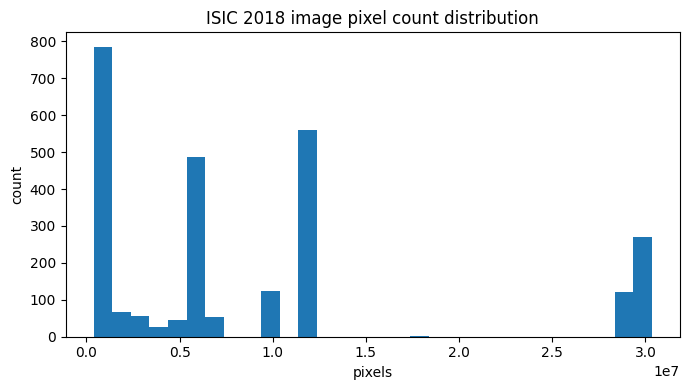

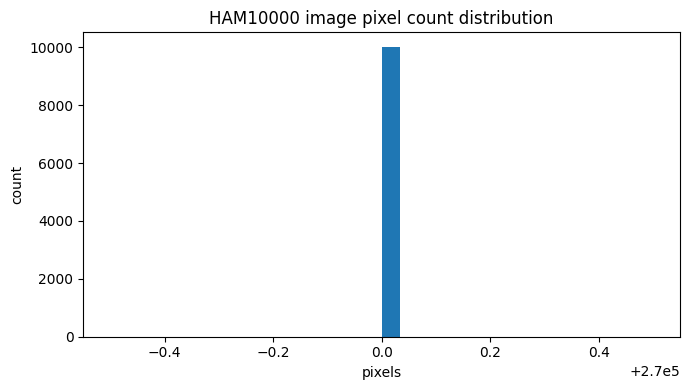

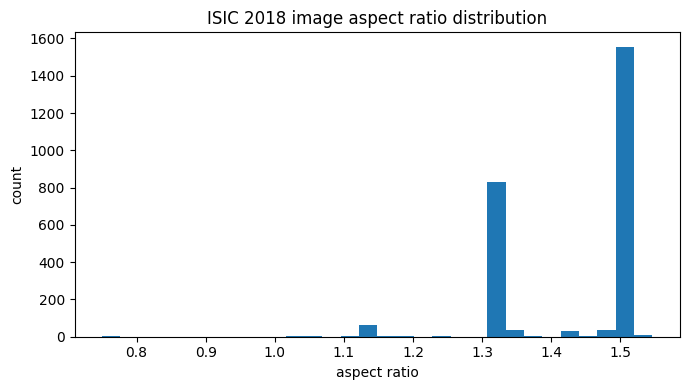

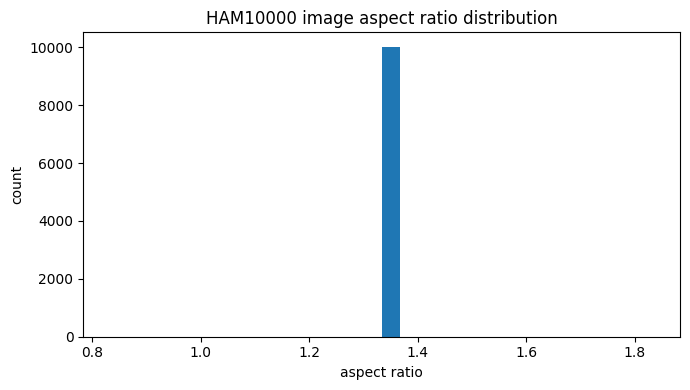

In [8]:
def resolution_df(img_dir: Path, suffix: str) -> pd.DataFrame:
    paths = list_files(img_dir, suffix)

    rows = []
    for p in paths:
        h, w = image_hw(p)
        rows.append({
            "stem": p.stem,
            "height": h,
            "width": w,
            "pixels": h * w,
            "aspect_ratio": w / h
        })
    return pd.DataFrame(rows)

isic_res = resolution_df(ISIC_IMG_DIR, ".jpg")
ham_res = resolution_df(HAM_IMG_DIR, ".jpg")

print("ISIC resolution summary:")
display(isic_res[["height", "width", "pixels", "aspect_ratio"]].describe())

print("HAM resolution summary:")
display(ham_res[["height", "width", "pixels", "aspect_ratio"]].describe())

# Plots of pixel count distributions
plt.figure(figsize=(7, 4))
plt.hist(isic_res["pixels"], bins=30)
plt.title("ISIC 2018 image pixel count distribution")
plt.xlabel("pixels")
plt.ylabel("count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(ham_res["pixels"], bins=30)
plt.title("HAM10000 image pixel count distribution")
plt.xlabel("pixels")
plt.ylabel("count")
plt.tight_layout()
plt.show()


# Plots of aspect ratio distributions
plt.figure(figsize=(7, 4))
plt.hist(isic_res["aspect_ratio"], bins=30)
plt.title("ISIC 2018 image aspect ratio distribution")
plt.xlabel("aspect ratio")
plt.ylabel("count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(ham_res["aspect_ratio"], bins=30)
plt.title("HAM10000 image aspect ratio distribution")
plt.xlabel("aspect ratio")
plt.ylabel("count")
plt.tight_layout()
plt.show()

## 7. Image-mask size consistency

Matching stems are not enough. We also need matching dimensions.

In [9]:
def pair_size_check(img_dir: Path, mask_dir: Path, img_suffix=".jpg", mask_suffix=".png") -> pd.DataFrame:
    common = sorted(stems(img_dir, img_suffix) & stems(mask_dir, mask_suffix))
    rows = []

    for stem in common:
        img_path = img_dir / f"{stem}{img_suffix}"
        mask_path = mask_dir / f"{stem}{mask_suffix}"

        img_h, img_w = image_hw(img_path)
        mask_h, mask_w = image_hw(mask_path)

        rows.append({
            "stem": stem,
            "img_h": img_h,
            "img_w": img_w,
            "mask_h": mask_h,
            "mask_w": mask_w,
            "same_size": (img_h == mask_h) and (img_w == mask_w)
        })

    return pd.DataFrame(rows)

isic_pair_sizes = pair_size_check(ISIC_IMG_DIR, ISIC_MASK_DIR)
ham_pair_sizes = pair_size_check(HAM_IMG_DIR, HAM_MASK_DIR)

print("ISIC same-size counts:")
display(isic_pair_sizes["same_size"].value_counts())

print("HAM same-size counts:")
display(ham_pair_sizes["same_size"].value_counts())

display(isic_pair_sizes.loc[~isic_pair_sizes["same_size"]].head(10))
display(ham_pair_sizes.loc[~ham_pair_sizes["same_size"]].head(10))

ISIC same-size counts:


same_size
True    2594
Name: count, dtype: int64

HAM same-size counts:


same_size
True    10015
Name: count, dtype: int64

,stem,img_h,img_w,mask_h,mask_w,same_size


,stem,img_h,img_w,mask_h,mask_w,same_size


## 8. Mask coverage statistics

Mask coverage = fraction of image pixels that belong to the lesion.
This is useful later for XAI analysis and pseudo-concept generation.

ISIC mask coverage summary:


count    2594.000000
mean        0.214021
std         0.208366
min         0.002977
25%         0.051731
50%         0.138084
75%         0.318733
max         0.986650
Name: mask_coverage, dtype: float64

HAM mask coverage summary:


count    10015.000000
mean         0.266325
std          0.188419
min          0.003856
25%          0.119504
50%          0.222307
75%          0.374139
max          1.000000
Name: mask_coverage, dtype: float64

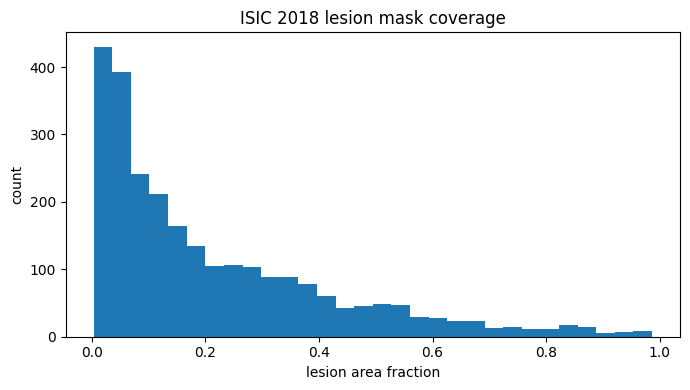

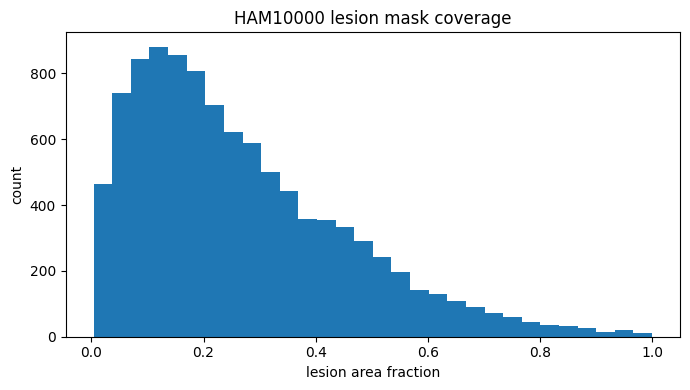

In [10]:
def coverage_df(mask_dir: Path, suffix: str) -> pd.DataFrame:
    paths = list_files(mask_dir, suffix)
    rows = []

    for p in paths:
        rows.append({
            "stem": p.stem,
            "mask_coverage": mask_coverage(p)
        })

    return pd.DataFrame(rows)

isic_cov = coverage_df(ISIC_MASK_DIR, ".png")
ham_cov = coverage_df(HAM_MASK_DIR, ".png")

print("ISIC mask coverage summary:")
display(isic_cov["mask_coverage"].describe())

print("HAM mask coverage summary:")
display(ham_cov["mask_coverage"].describe())

## Plots of mask coverage distributions
plt.figure(figsize=(7, 4))
plt.hist(isic_cov["mask_coverage"], bins=30)
plt.title("ISIC 2018 lesion mask coverage")
plt.xlabel("lesion area fraction")
plt.ylabel("count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(ham_cov["mask_coverage"], bins=30)
plt.title("HAM10000 lesion mask coverage")
plt.xlabel("lesion area fraction")
plt.ylabel("count")
plt.tight_layout()
plt.show()

/tmp/ipykernel_62024/3054073079.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


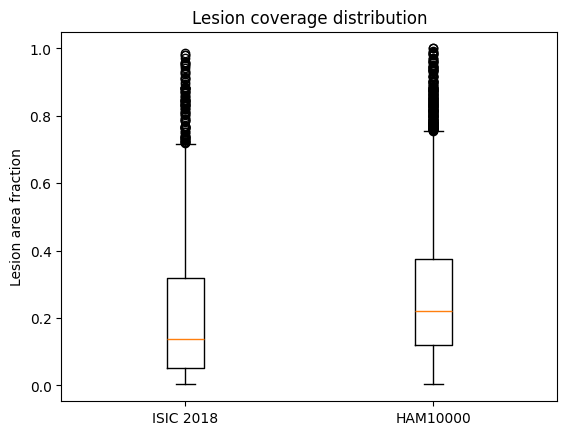

In [11]:
plt.boxplot(
    [isic_cov.mask_coverage, ham_cov.mask_coverage],
    labels=["ISIC 2018", "HAM10000"]
)
plt.ylabel("Lesion area fraction")
plt.title("Lesion coverage distribution")
plt.show()

## 9. HAM10000 metadata and class distribution

In [12]:
# Load and inspect HAM10000 metadata

ham_meta = pd.read_csv(HAM_META)

print(ham_meta.shape)
ham_meta.head()
ham_meta.info()
ham_meta["dx"].value_counts()



(10015, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
 7   dataset       10015 non-null  object 
dtypes: float64(1), object(7)
memory usage: 626.1+ KB


dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

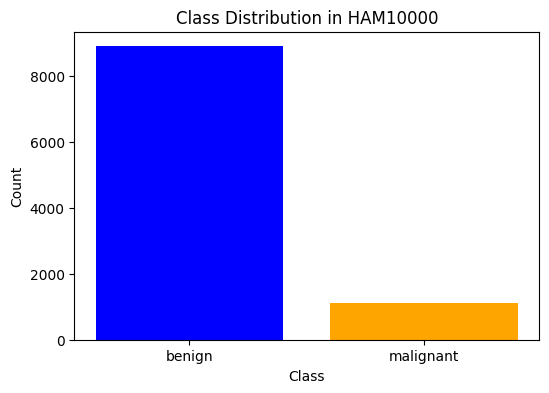

In [13]:
# Binary target mapping
ham_meta["label"] = ham_meta["dx"].apply(lambda x: 1 if x == "mel" else 0)
ham_meta["label_name"] = ham_meta["dx"].apply(lambda x: "malignant" if x == "mel" else "benign")
ham_meta[["image_id", "dx", "label", "label_name"]].head()

# Inspect class distribution
class_counts = ham_meta["label_name"].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(class_counts.index, class_counts.values, color=["blue", "orange"])
plt.title("Class Distribution in HAM10000")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()  

## 10. Additional mask diagnostics

We add two preprocessing diagnostics that may affect later XAI evaluation:

- **border-touching lesions**: masks that touch one or more image borders
- **tiny lesions**: masks with very small area fraction

These cases are not removed here. They are flagged in the inventory so they can be analysed later.

In [24]:
def border_touch_info(mask_path: Path) -> dict:
    """
    Detect whether the lesion mask touches the image borders.
    """
    mask = load_mask_bin(mask_path)

    top = bool(mask[0, :].any())
    bottom = bool(mask[-1, :].any())
    left = bool(mask[:, 0].any())
    right = bool(mask[:, -1].any())

    n_borders_touched = sum([top, bottom, left, right])

    return {
        "stem": mask_path.stem,
        "touch_top": top,
        "touch_bottom": bottom,
        "touch_left": left,
        "touch_right": right,
        "touches_any_border": n_borders_touched > 0,
        "n_borders_touched": n_borders_touched
    }


def border_touch_df(mask_dir: Path, suffix=".png") -> pd.DataFrame:
    rows = []
    for mask_path in list_files(mask_dir, suffix):
        rows.append(border_touch_info(mask_path))
    return pd.DataFrame(rows)


def classify_mask_size(coverage: float) -> str:
    """
    Classify lesion size based on mask coverage fraction.
    """
    if coverage < 0.01:
        return "very_tiny"
    elif coverage < 0.02:
        return "tiny"
    elif coverage < 0.05:
        return "small"
    else:
        return "normal"

In [23]:
isic_border = border_touch_df(ISIC_MASK_DIR)
ham_border = border_touch_df(HAM_MASK_DIR)

print("ISIC border-touch summary:")
display(isic_border["touches_any_border"].value_counts())
display(isic_border["n_borders_touched"].value_counts().sort_index())

print("HAM border-touch summary:")
display(ham_border["touches_any_border"].value_counts())
display(ham_border["n_borders_touched"].value_counts().sort_index())


isic_cov["mask_size_class"] = isic_cov["mask_coverage"].apply(classify_mask_size)
ham_cov["mask_size_class"] = ham_cov["mask_coverage"].apply(classify_mask_size)

print("ISIC mask size classes:")
display(isic_cov["mask_size_class"].value_counts())

print("HAM mask size classes:")
display(ham_cov["mask_size_class"].value_counts())

isic_diag = isic_cov.merge(isic_border, on="stem", how="left")
ham_diag = ham_cov.merge(ham_border, on="stem", how="left")

display(isic_diag.head())
display(ham_diag.head())

print("ISIC suspicious cases:")
isic_suspicious = isic_diag.loc[
    (isic_diag["touches_any_border"]) | (isic_diag["mask_coverage"] < 0.02)
].copy()
display(isic_suspicious.head(20))
print("Count:", len(isic_suspicious))

print("HAM suspicious cases:")
ham_suspicious = ham_diag.loc[
    (ham_diag["touches_any_border"]) | (ham_diag["mask_coverage"] < 0.02)
].copy()
display(ham_suspicious.head(20))
print("Count:", len(ham_suspicious))




ISIC border-touch summary:


touches_any_border
False    2388
True      206
Name: count, dtype: int64

n_borders_touched
0    2388
1     131
2      52
3      19
4       4
Name: count, dtype: int64

HAM border-touch summary:


touches_any_border
False    8421
True     1594
Name: count, dtype: int64

...

ISIC suspicious cases:


,stem,mask_coverage,mask_size_class,touch_top,touch_bottom,touch_left,touch_right,touches_any_border,n_borders_touched
113,ISIC_0000125,0.014539,tiny,False,False,False,False,False,0
145,ISIC_0000160,0.711055,normal,False,True,True,False,True,2
168,ISIC_0000187,0.812524,normal,False,True,False,False,True,1
169,ISIC_0000188,0.584618,normal,False,True,False,False,True,1
171,ISIC_0000190,0.602302,normal,False,True,False,False,True,1
181,ISIC_0000202,0.807041,normal,False,False,True,False,True,1
182,ISIC_0000203,0.932471,normal,True,False,True,True,True,3
183,ISIC_0000204,0.506435,normal,True,False,False,False,True,1
187,ISIC_0000208,0.723014,normal,False,True,False,True,True,2
191,ISIC_0000212,0.687361,normal,False,False,False,True,True,1


Count: 403
HAM suspicious cases:


,stem,mask_coverage,mask_size_class,touch_top,touch_bottom,touch_left,touch_right,touches_any_border,n_borders_touched
3,ISIC_0024309,0.356407,normal,False,True,False,False,True,1
36,ISIC_0024342,0.238133,normal,True,False,False,False,True,1
39,ISIC_0024345,0.383174,normal,False,True,False,False,True,1
40,ISIC_0024346,0.173837,normal,True,False,False,False,True,1
53,ISIC_0024359,0.371793,normal,True,False,False,False,True,1
55,ISIC_0024361,0.612793,normal,False,True,False,True,True,2
59,ISIC_0024365,0.578681,normal,False,False,False,True,True,1
65,ISIC_0024371,0.660519,normal,True,False,False,True,True,2
69,ISIC_0024375,0.017067,tiny,False,False,False,False,False,0
72,ISIC_0024378,0.005696,very_tiny,False,False,False,False,False,0


Count: 1781


## 11. Build inventory manifests


In [25]:
def build_inventory(img_dir: Path, mask_dir: Path, img_suffix=".jpg", mask_suffix=".png") -> pd.DataFrame:
    img_stems = stems(img_dir, img_suffix)
    mask_stems = stems(mask_dir, mask_suffix)
    all_stems = sorted(img_stems | mask_stems)

    rows = []
    for stem in all_stems:
        img_exists = stem in img_stems
        mask_exists = stem in mask_stems

        row = {
            "stem": stem,
            "image_exists": img_exists,
            "mask_exists": mask_exists
        }

        if img_exists:
            img_path = img_dir / f"{stem}{img_suffix}"
            img_h, img_w = image_hw(img_path)
            row["img_h"] = img_h
            row["img_w"] = img_w
            row["pixels"] = img_h * img_w
            row["aspect_ratio"] = img_w / img_h
        else:
            row["img_h"] = np.nan
            row["img_w"] = np.nan
            row["pixels"] = np.nan
            row["aspect_ratio"] = np.nan

        if mask_exists:
            mask_path = mask_dir / f"{stem}{mask_suffix}"
            mask_h, mask_w = image_hw(mask_path)
            cov = mask_coverage(mask_path)

            row["mask_h"] = mask_h
            row["mask_w"] = mask_w
            row["mask_coverage"] = cov
            row["mask_pixels"] = int(round(cov * mask_h * mask_w))
            row["mask_size_class"] = classify_mask_size(cov)
        else:
            row["mask_h"] = np.nan
            row["mask_w"] = np.nan
            row["mask_coverage"] = np.nan
            row["mask_pixels"] = np.nan
            row["mask_size_class"] = np.nan

        row["same_size"] = (
            img_exists and mask_exists and
            row["img_h"] == row["mask_h"] and
            row["img_w"] == row["mask_w"]
        )

        rows.append(row)

    return pd.DataFrame(rows)

In [26]:
isic_inventory = build_inventory(ISIC_IMG_DIR, ISIC_MASK_DIR)
ham_inventory = build_inventory(HAM_IMG_DIR, HAM_MASK_DIR)

isic_inventory = isic_inventory.merge(
    isic_border[[
        "stem",
        "touch_top",
        "touch_bottom",
        "touch_left",
        "touch_right",
        "touches_any_border",
        "n_borders_touched"
    ]],
    on="stem",
    how="left"
)

ham_inventory = ham_inventory.merge(
    ham_border[[
        "stem",
        "touch_top",
        "touch_bottom",
        "touch_left",
        "touch_right",
        "touches_any_border",
        "n_borders_touched"
    ]],
    on="stem",
    how="left"
)

display(isic_inventory.head())
display(ham_inventory.head())

,stem,image_exists,mask_exists,img_h,img_w,pixels,aspect_ratio,mask_h,mask_w,mask_coverage,mask_pixels,mask_size_class,same_size,touch_top,touch_bottom,touch_left,touch_right,touches_any_border,n_borders_touched
0,ISIC_0000000,True,True,767,1022,783874,1.332464,767,1022,0.469732,368211,normal,True,False,False,False,False,False,0
1,ISIC_0000001,True,True,767,1022,783874,1.332464,767,1022,0.070504,55266,normal,True,False,False,False,False,False,0
2,ISIC_0000003,True,True,767,1022,783874,1.332464,767,1022,0.336569,263828,normal,True,False,False,False,False,False,0
3,ISIC_0000004,True,True,767,1022,783874,1.332464,767,1022,0.344974,270416,normal,True,False,False,False,False,False,0
4,ISIC_0000006,True,True,767,1022,783874,1.332464,767,1022,0.091723,71899,normal,True,False,False,False,False,False,0


,stem,image_exists,mask_exists,img_h,img_w,pixels,aspect_ratio,mask_h,mask_w,mask_coverage,mask_pixels,mask_size_class,same_size,touch_top,touch_bottom,touch_left,touch_right,touches_any_border,n_borders_touched
0,ISIC_0024306,True,True,450,600,270000,1.333333,450,600,0.342774,92549,normal,True,False,False,False,False,False,0
1,ISIC_0024307,True,True,450,600,270000,1.333333,450,600,0.416826,112543,normal,True,False,False,False,False,False,0
2,ISIC_0024308,True,True,450,600,270000,1.333333,450,600,0.370004,99901,normal,True,False,False,False,False,False,0
3,ISIC_0024309,True,True,450,600,270000,1.333333,450,600,0.356407,96230,normal,True,False,True,False,False,True,1
4,ISIC_0024310,True,True,450,600,270000,1.333333,450,600,0.240785,65012,normal,True,False,False,False,False,False,0


In [28]:
ham_inventory = ham_inventory.merge(
    ham_meta[["image_id", "dx", "label", "label_name"]],
    left_on="stem",
    right_on="image_id",
    how="left"
).drop(columns=["image_id"])

display(ham_inventory.head())

,stem,image_exists,mask_exists,img_h,img_w,pixels,aspect_ratio,mask_h,mask_w,mask_coverage,mask_pixels,mask_size_class,same_size,touch_top,touch_bottom,touch_left,touch_right,touches_any_border,n_borders_touched,dx,label,label_name
0,ISIC_0024306,True,True,450,600,270000,1.333333,450,600,0.342774,92549,normal,True,False,False,False,False,False,0,nv,0,benign
1,ISIC_0024307,True,True,450,600,270000,1.333333,450,600,0.416826,112543,normal,True,False,False,False,False,False,0,nv,0,benign
2,ISIC_0024308,True,True,450,600,270000,1.333333,450,600,0.370004,99901,normal,True,False,False,False,False,False,0,nv,0,benign
3,ISIC_0024309,True,True,450,600,270000,1.333333,450,600,0.356407,96230,normal,True,False,True,False,False,True,1,nv,0,benign
4,ISIC_0024310,True,True,450,600,270000,1.333333,450,600,0.240785,65012,normal,True,False,False,False,False,False,0,mel,1,malignant


In [33]:
def inventory_diagnostic_summary(df: pd.DataFrame, name: str):
    print(f"\n{name} - same_size")
    display(df["same_size"].value_counts())

    print(f"{name} - mask_size_class")
    display(df["mask_size_class"].value_counts())

    print(f"{name} - touches_any_border")
    display(df["touches_any_border"].value_counts())

    print(f"{name} - n_borders_touched")
    display(df["n_borders_touched"].value_counts().sort_index())

    print(f"{name} - border-touch rate")
    print(f"{100 * df['touches_any_border'].mean():.2f}%")

inventory_diagnostic_summary(isic_inventory, "ISIC")
inventory_diagnostic_summary(ham_inventory, "HAM")


ISIC - same_size


same_size
True    2594
Name: count, dtype: int64

ISIC - mask_size_class


mask_size_class
normal       1970
small         427
tiny          149
very_tiny      48
Name: count, dtype: int64

ISIC - touches_any_border


...

HAM - touches_any_border


touches_any_border
False    8421
True     1594
Name: count, dtype: int64

HAM - n_borders_touched


n_borders_touched
0    8421
1     908
2     396
3     183
4     107
Name: count, dtype: int64

HAM - border-touch rate
15.92%


In [34]:
print("ISIC border-touch percentage:")
print(isic_inventory["touches_any_border"].mean())

print("HAM border-touch percentage:")
print(ham_inventory["touches_any_border"].mean())

ISIC border-touch percentage:
0.07941403238242097
HAM border-touch percentage:
0.15916125811283074


## 12. Gallery

In [18]:
def show_triplets(stems_list, img_dir: Path, mask_dir: Path, n=6, title="Gallery"):
    chosen = stems_list[:n]
    fig, axes = plt.subplots(len(chosen), 3, figsize=(11, 4 * len(chosen)))

    if len(chosen) == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, stem in enumerate(chosen):
        img = load_rgb_u8(img_dir / f"{stem}.jpg")
        mask = load_mask_bin(mask_dir / f"{stem}.png")
        overlay = overlay_mask(img, mask, alpha=0.4)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"{stem} - image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(mask, cmap="gray")
        axes[i, 1].set_title(f"mask (coverage={mask.mean():.3f})")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title("overlay")
        axes[i, 2].axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

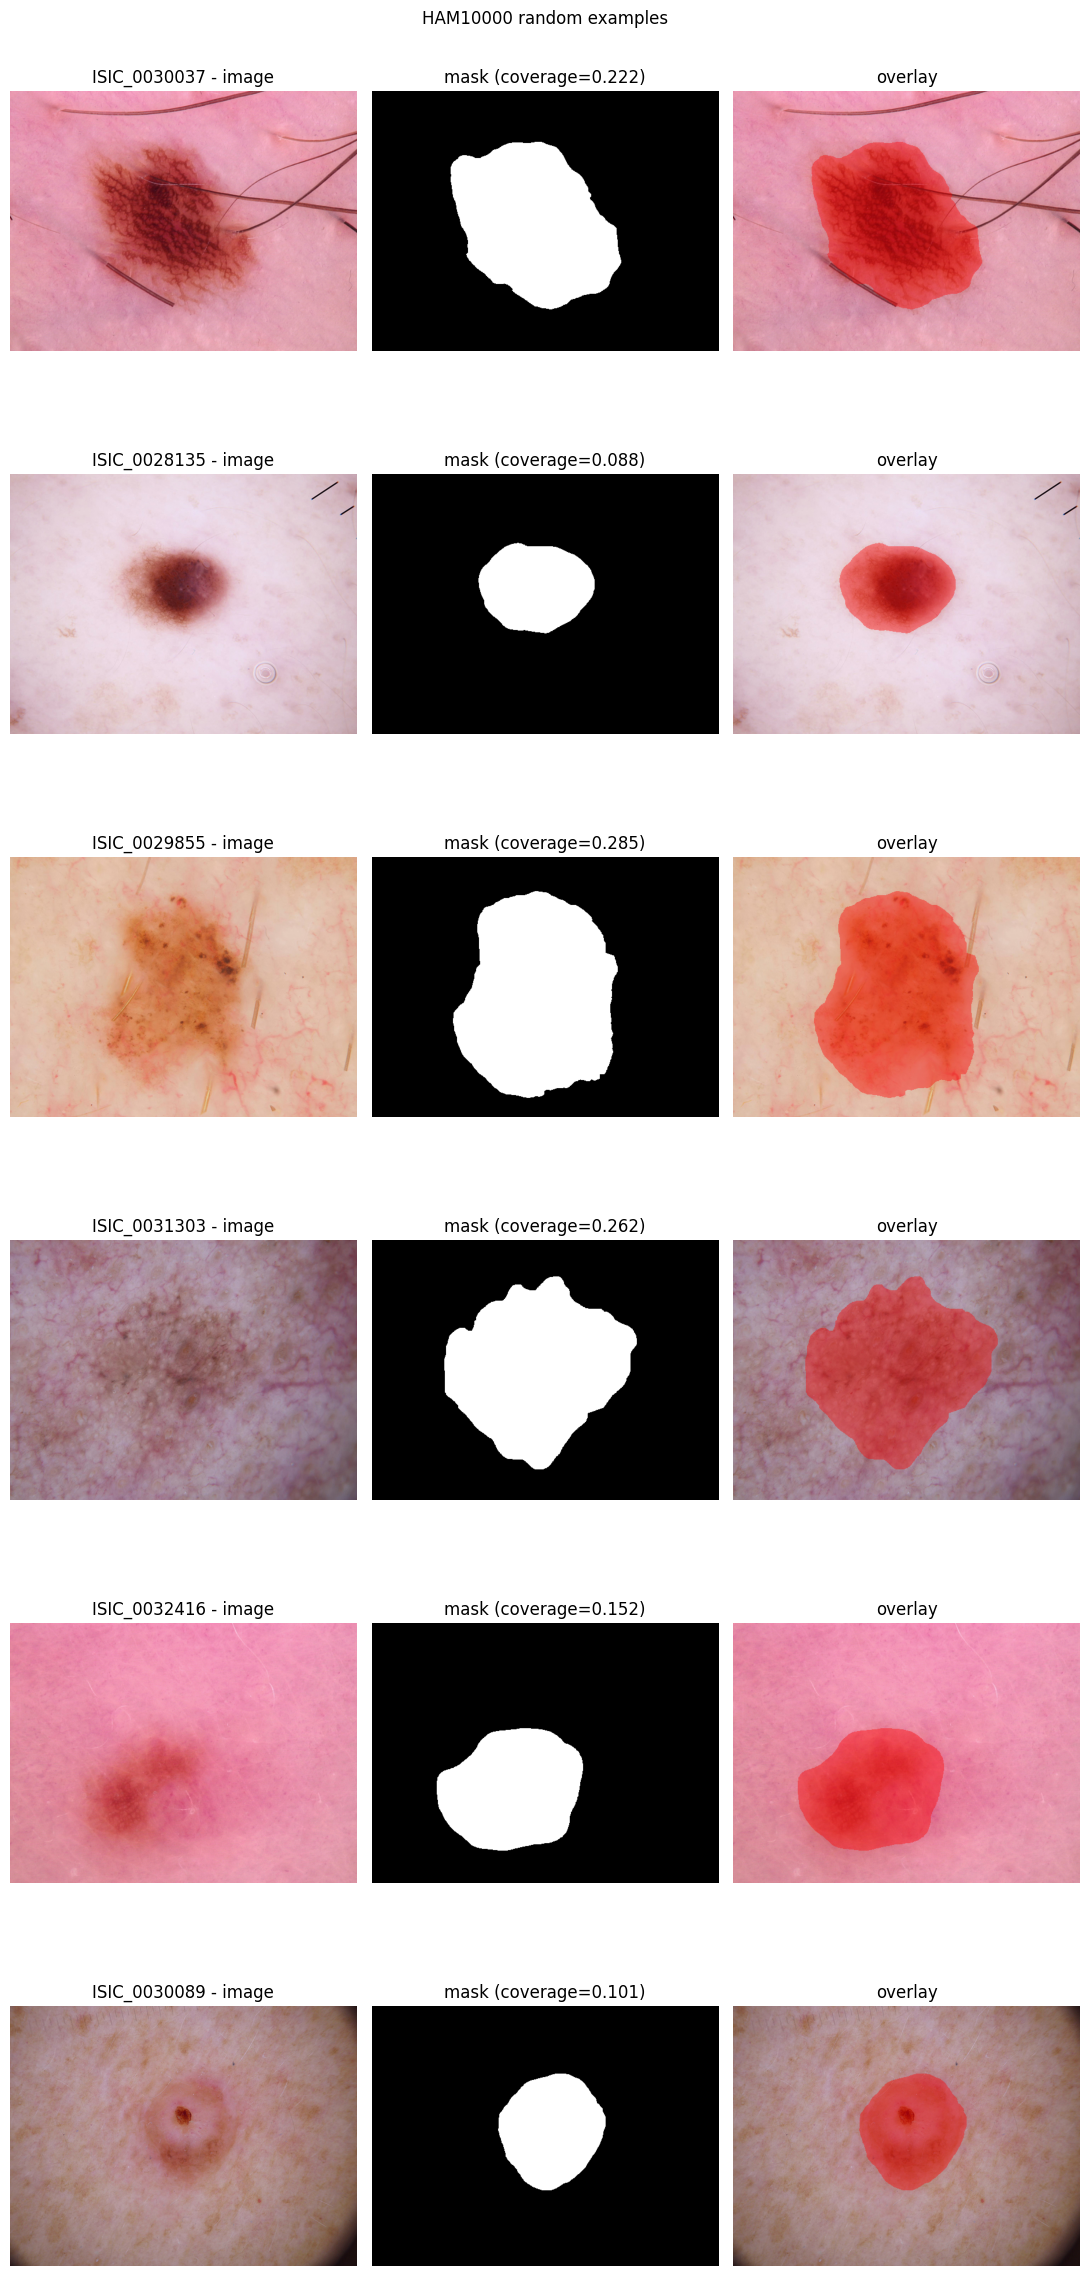

In [19]:
# random examples from HAM
random_ham_stems = random.sample(sorted(list(ham_pairs)), min(6, len(ham_pairs)))
show_triplets(random_ham_stems, HAM_IMG_DIR, HAM_MASK_DIR, n=len(random_ham_stems), title="HAM10000 random examples")

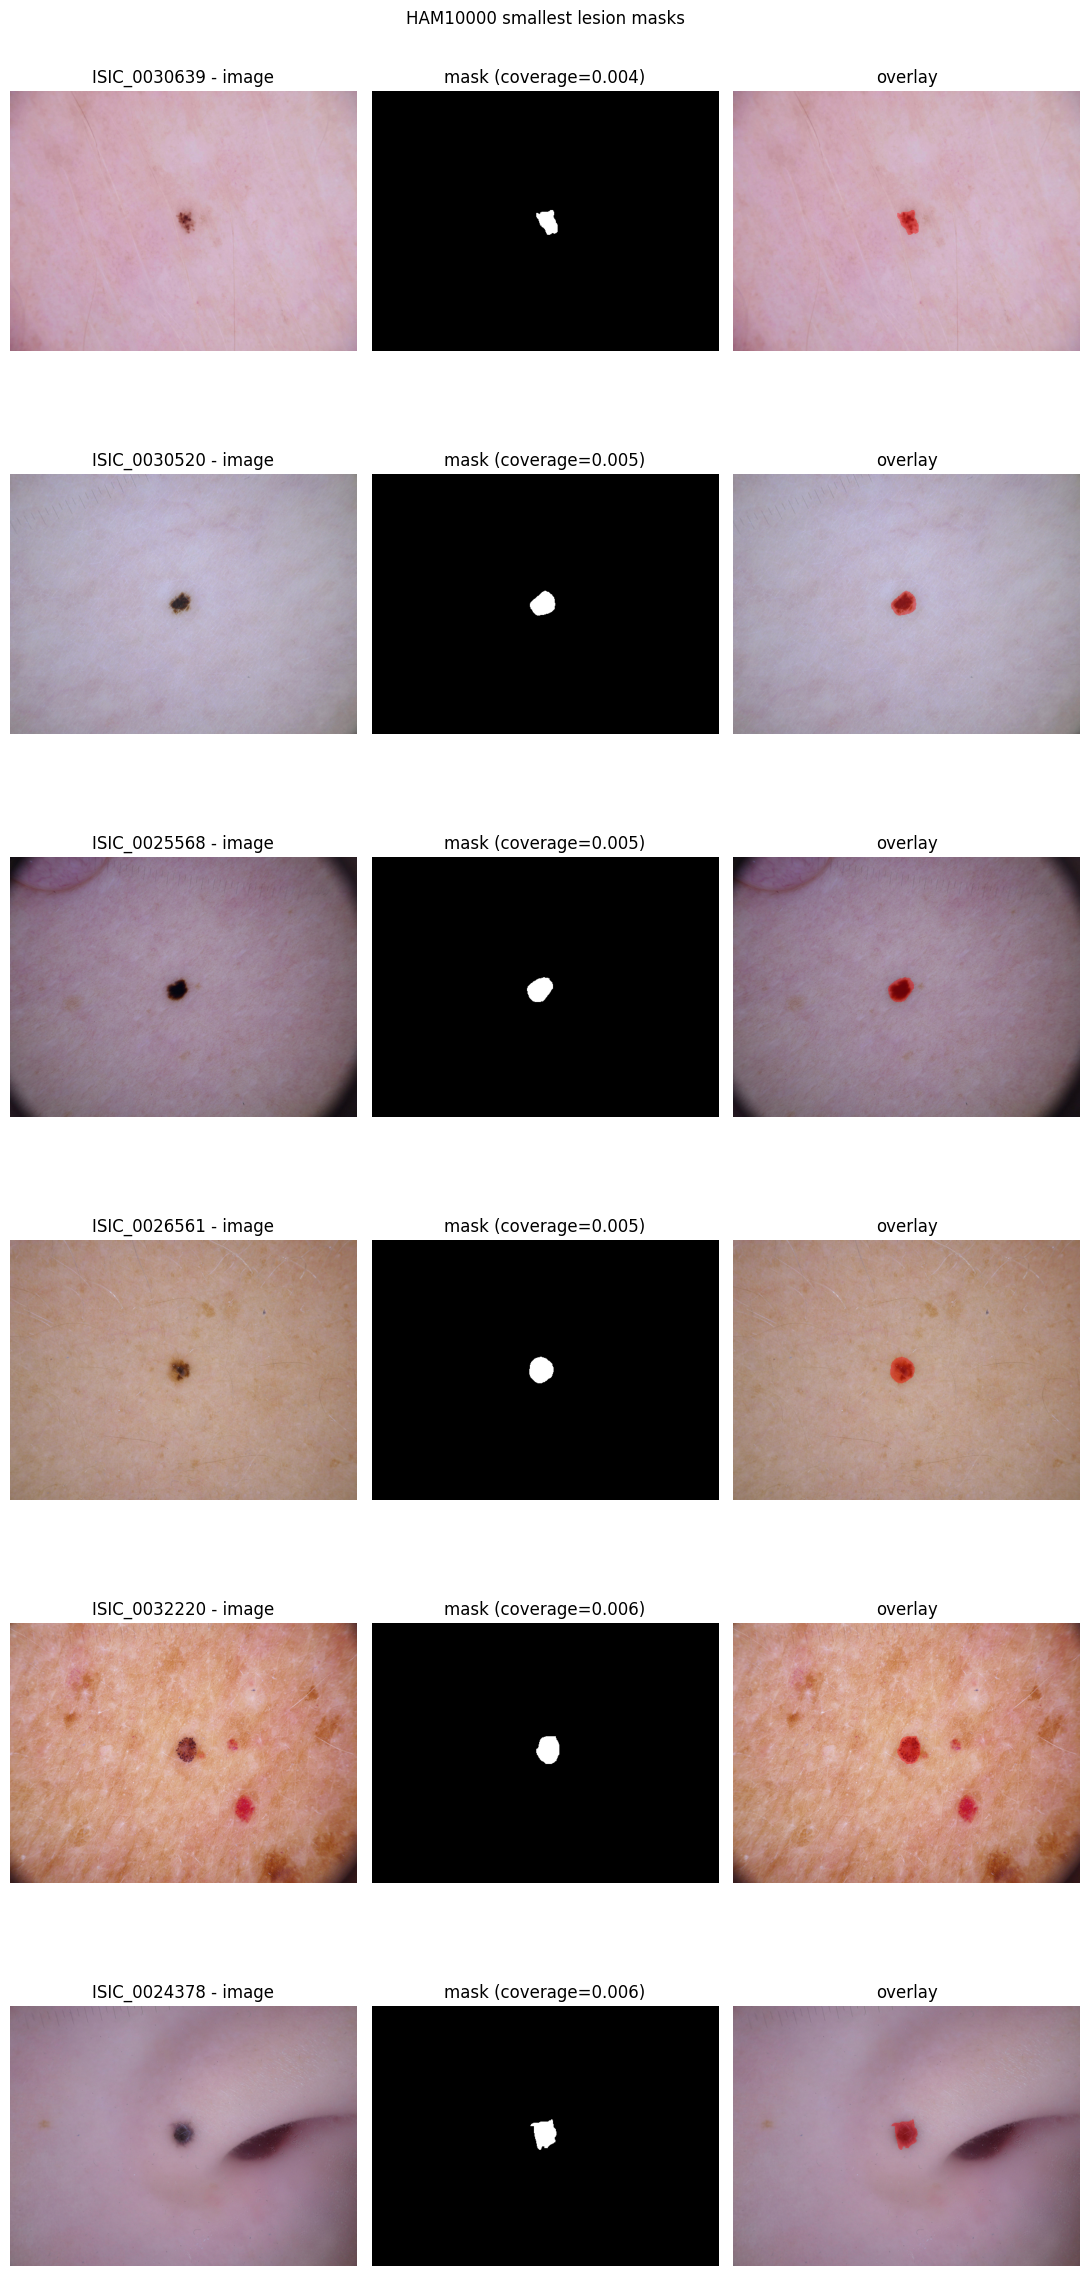

In [20]:
# smallest lesions in HAM
smallest_ham = (
    ham_inventory.loc[ham_inventory["mask_exists"]]
    .sort_values("mask_coverage", ascending=True)["stem"]
    .tolist()
)

show_triplets(smallest_ham, HAM_IMG_DIR, HAM_MASK_DIR, n=min(6, len(smallest_ham)), title="HAM10000 smallest lesion masks")

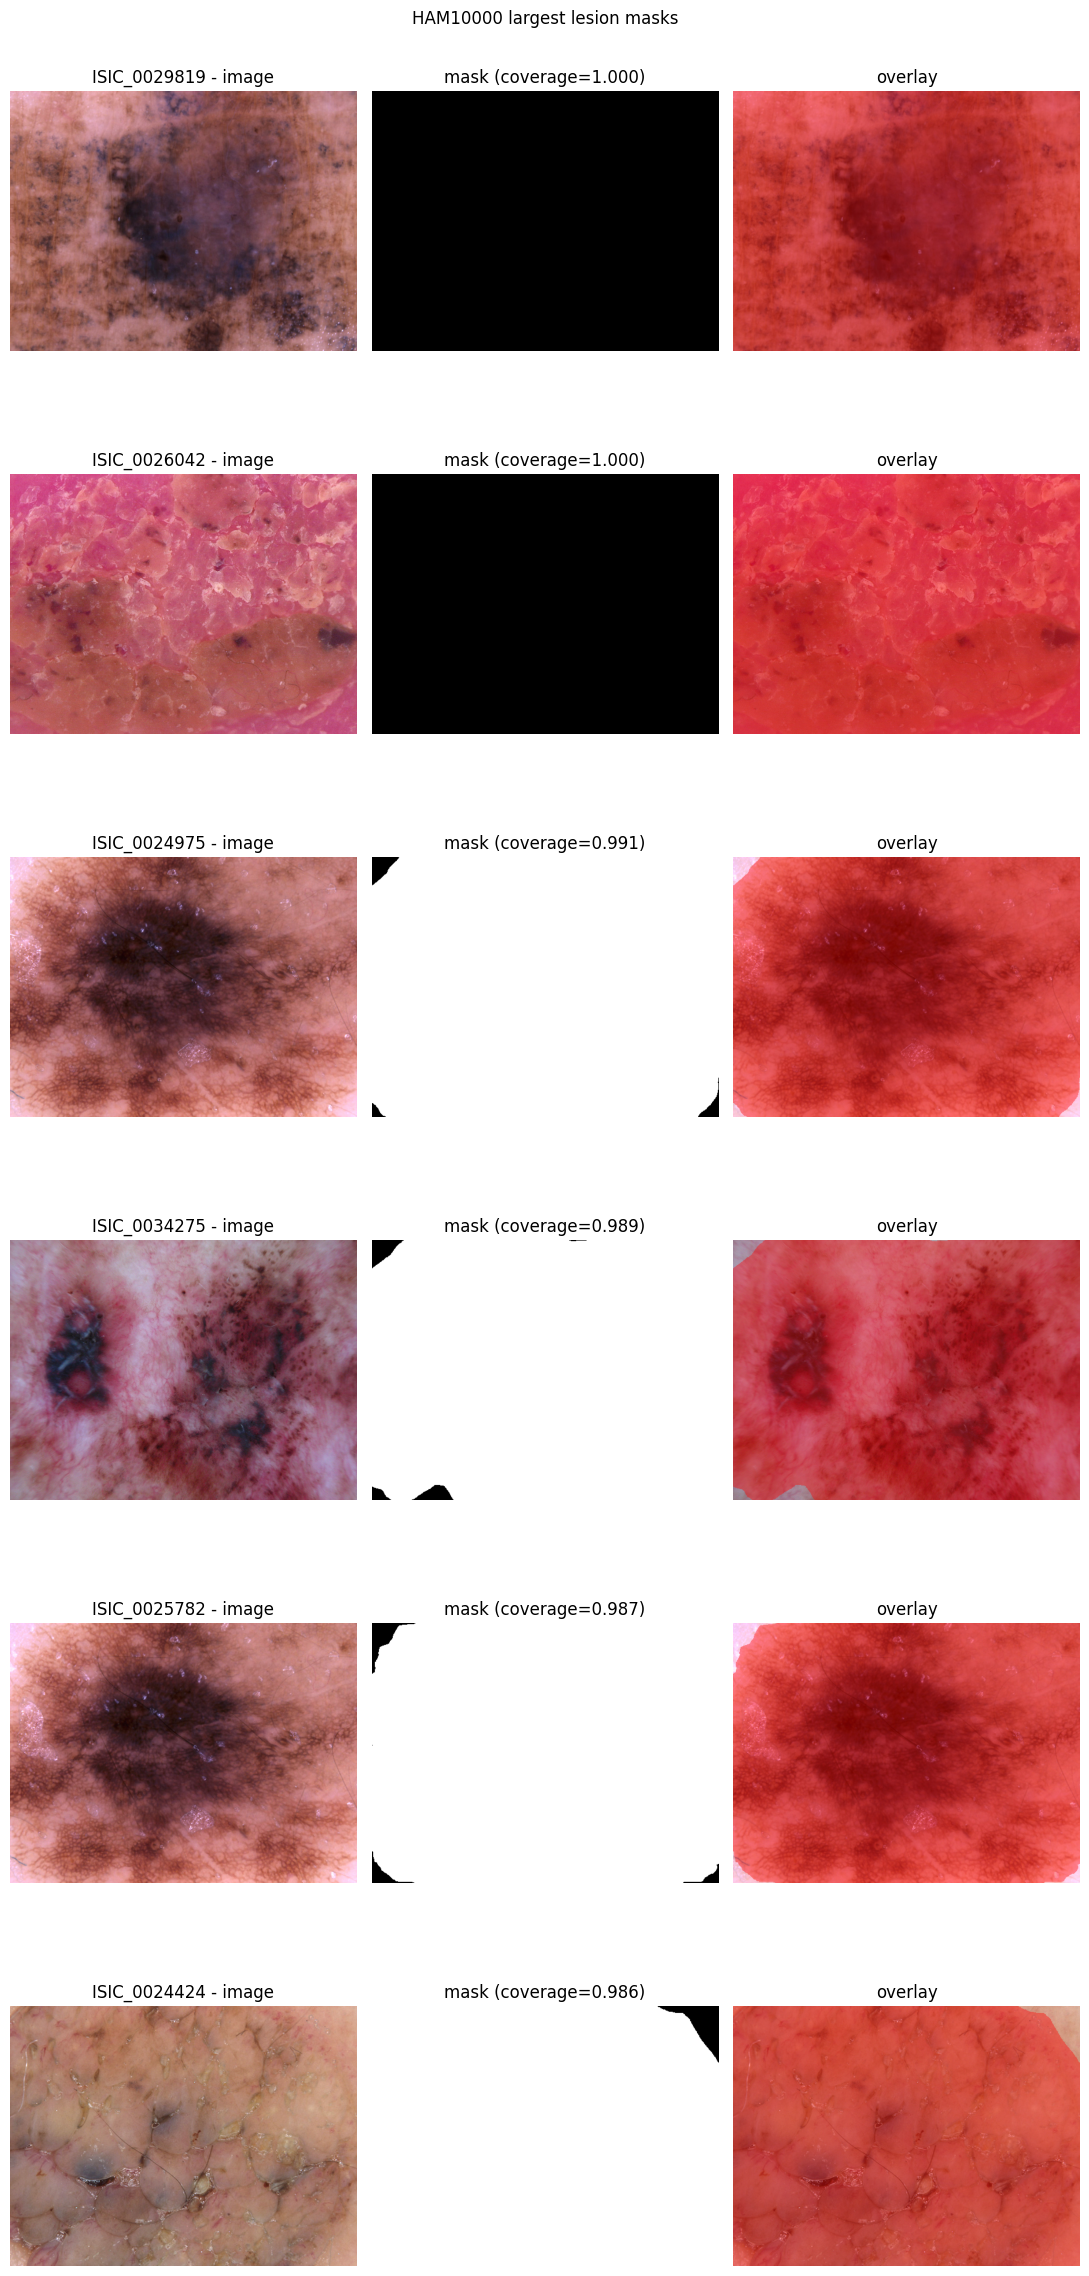

In [21]:
# largest lesions in HAM
largest_ham = (
    ham_inventory.loc[ham_inventory["mask_exists"]]
    .sort_values("mask_coverage", ascending=False)["stem"]
    .tolist()
)

show_triplets(largest_ham, HAM_IMG_DIR, HAM_MASK_DIR, n=min(6, len(largest_ham)), title="HAM10000 largest lesion masks")

## 12. Save clean invenmtory manifests

In [35]:
OUT_DIR = ROOT / "data" / "preprocessed_manifests"
OUT_DIR.mkdir(parents=True, exist_ok=True)

isic_inventory_path = OUT_DIR / "isic2018_inventory.csv"
ham_inventory_path = OUT_DIR / "ham10000_inventory.csv"

isic_inventory.to_csv(isic_inventory_path, index=False)
ham_inventory.to_csv(ham_inventory_path, index=False)

print("Saved:", isic_inventory_path.resolve())
print("Saved:", ham_inventory_path.resolve())

Saved: /home/tbeliere/Projects/DCU/2026-mcm-XAI-skin-lesion/data/preprocessed_manifests/isic2018_inventory.csv
Saved: /home/tbeliere/Projects/DCU/2026-mcm-XAI-skin-lesion/data/preprocessed_manifests/ham10000_inventory.csv
